# FFT Example 2: Noisy Multi-Frequency Sinusoidal Signal

Generate a noisy signal containing 2 Hz, 5 Hz, and 8 Hz components, compute its FFT, and identify the frequency peaks from the amplitude and power spectra.

## Generate the time series

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fs = 100.0         # sampling frequency [Hz]
T = 10.0           # total duration [s]

N = int(fs * T)
t = np.arange(N) / fs

y_clean = (
    2.0 * np.sin(2 * np.pi * 2.0 * t)
    + 1.2 * np.sin(2 * np.pi * 5.0 * t)
    + 0.6 * np.sin(2 * np.pi * 8.0 * t)
)

noise = 0.8 * np.random.randn(N)
y = y_clean + noise

print(f"N = {N}")
print(f"Sampling interval = {1/fs:.3f} s")
print(f"Frequency resolution = {1/T:.3f} Hz")


N = 1000
Sampling interval = 0.010 s
Frequency resolution = 0.100 Hz


## FFT and power spectrum

In [2]:
Y = np.fft.fft(y)
freq = np.fft.fftfreq(N, d=1/fs)

mask = freq >= 0
freq_pos = freq[mask]
Y_pos = Y[mask]

amplitude = 2.0 * np.abs(Y_pos) / N
amplitude[0] /= 2.0

power = np.abs(Y_pos)**2 / N


## Plot 1: initial signal with noise

/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: sav

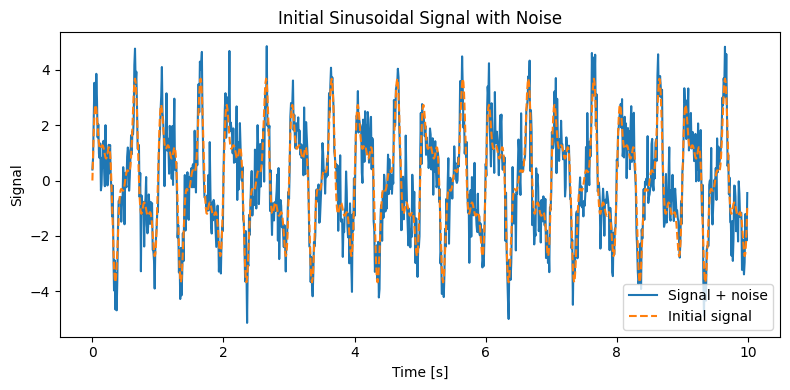

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label="Signal + noise")
plt.plot(t, y_clean, "--", label="Initial signal")
plt.xlabel("Time [s]")
plt.ylabel("Signal")
plt.title("Initial Sinusoidal Signal with Noise")
plt.legend()
plt.tight_layout()
plt.show()


## Plot 2: FFT amplitude spectrum

/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: sav

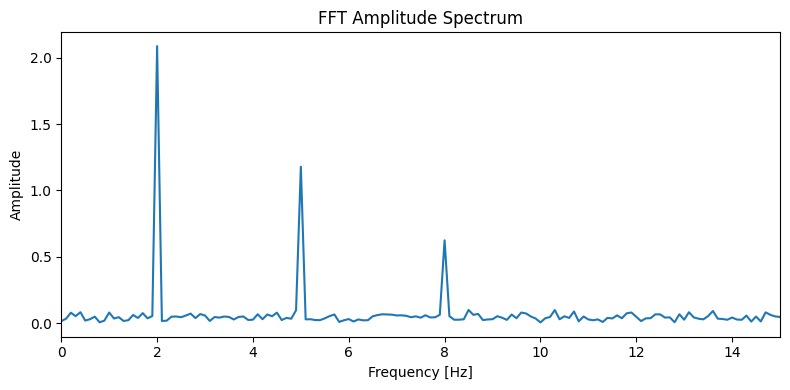

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(freq_pos, amplitude)
plt.xlim(0, 15)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT Amplitude Spectrum")
plt.tight_layout()
plt.show()


## Plot 3: power spectrum

/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: sav

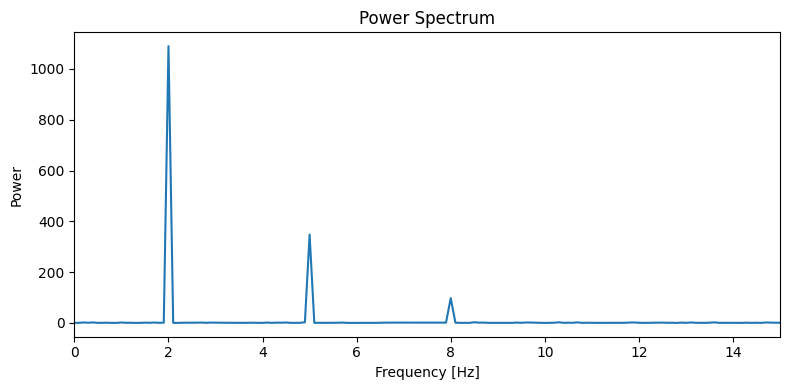

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(freq_pos, power)
plt.xlim(0, 15)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power")
plt.title("Power Spectrum")
plt.tight_layout()
plt.show()
